<a href="https://colab.research.google.com/github/rahna1369/Supply-Chain-Delay-Prediction/blob/main/Supply_chain_delay_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost optuna torch scikit-learn seaborn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, accuracy_score
from xgboost import XGBRegressor, XGBClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
print("Environment setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 13.2 MB/s eta 0:00:00
Environment setup complete.


###  Data Loading & Initial Inspection

In [2]:
file_path = '/content/global_supply_chain_risk_2026.csv'
print(f" Loading dataset from: '{file_path}'...")
df = pd.read_csv(file_path).drop_duplicates()
print(f"      Raw Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Actual Columns in  file ---")
print(df.columns.tolist())
print("-" * 262)
df.head()

 Loading dataset from: '/content/global_supply_chain_risk_2026.csv'...
      Raw Data Loaded: 5000 rows, 14 columns

--- Actual Columns in  file ---
['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,16-10-2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,24-04-2024,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,26-01-2024,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,08-10-2024,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,07-09-2024,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


Reads the raw shipment dataset, removes duplicate records to prevent data contamination, and outputs dataset dimensions along with the first few rows for validation.

### Date Parsing & Chronological Sorting

In [3]:
print("Parsing dates and sorting chronologically...")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values('Date').dropna(subset=['Date']).reset_index(drop=True)
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

Parsing dates and sorting chronologically...
Date Range: 2024-01-01 to 2025-12-31


Converts date strings to standard datetime objects using DD-MM-YYYY format, drops invalid dates, and sorts rows sequentially. Proper chronological order is required prior to generating sliding time-series windows.

### Domain Penalties & Target Delay Calculation

In [4]:
print("Applying domain penalties and calculating target delays...")
weather_delay = {'Clear': 0.0, 'Foggy': 0.5, 'Rainy': 1.2, 'Stormy': 2.5}
df['Weather_Penalty_Days'] = df['Weather_Condition'].map(weather_delay).fillna(0)
df['Adjusted_Lead_Time'] = df['Lead_Time_Days'] + df['Weather_Penalty_Days']

BASELINE_TRANSIT = 3.0
df['Tomorrow_Delay_Days'] = (df['Adjusted_Lead_Time'] - BASELINE_TRANSIT).clip(lower=0)

print(f"Target Delay Stats -> Min: {df['Tomorrow_Delay_Days'].min():.2f}, Max: {df['Tomorrow_Delay_Days'].max():.2f}, Mean: {df['Tomorrow_Delay_Days'].mean():.2f} days")

Applying domain penalties and calculating target delays...
Target Delay Stats -> Min: 0.00, Max: 233.39, Mean: 16.89 days


Maps weather conditions to numeric delay penalties, updates total transit lead times, and calculates Tomorrow_Delay_Days by measuring deviations beyond a 3-day baseline (clipped at zero).

### Cyclical Temporal Encoding & Feature Engineering

In [5]:
print("Creating temporal sine/cosine features and composite risk index...")
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Sin_DayOfWeek'] = np.sin(2 * np.pi * df['Day_of_Week'] / 7.0)
df['Cos_DayOfWeek'] = np.cos(2 * np.pi * df['Day_of_Week'] / 7.0)
df['Sin_Month'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Cos_Month'] = np.cos(2 * np.pi * df['Month'] / 12.0)

df['Distance_km_log'] = np.log1p(df['Distance_km'])
df['Weight_MT_log'] = np.log1p(df['Weight_MT'])
df['Risk_Composite_Index'] = (df['Geopolitical_Risk_Score'] * 0.6) + ((10 - df['Carrier_Reliability_Score']) * 0.4)
df['Transport_Intensity'] = df['Distance_km_log'] / (df['Weight_MT_log'] + 1e-5)

print(f"Feature Engineering Complete. Total Columns: {df.shape[1]}")

Creating temporal sine/cosine features and composite risk index...
Feature Engineering Complete. Total Columns: 27


Converts calendar components (day of week, month) into continuous sine and cosine waves to preserve cyclical relationships. Transforms skewed continuous inputs (distance, weight) via logarithms and builds a combined risk index combining geopolitical and carrier reliability scores.

### One-Hot Encoding & Feature Extraction

In [6]:
print("Performing one-hot encoding on categorical columns...")
cat_cols = ['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

exclude_cols = ['Shipment_ID', 'Date', 'Lead_Time_Days', 'Adjusted_Lead_Time', 'Tomorrow_Delay_Days', 'Disruption_Occurred', 'Day_of_Week', 'Month']
feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

X_raw = df_encoded[feature_cols].values
y_delay = df_encoded['Tomorrow_Delay_Days'].values
y_disruption = df_encoded['Disruption_Occurred'].values

print(f"      Feature Matrix Shape (X): {X_raw.shape}")
print(f"      Target Delay Days Shape (y_delay): {y_delay.shape}")
print(f"      Target Disruption Flag Shape (y_disruption): {y_disruption.shape}")

Performing one-hot encoding on categorical columns...
      Feature Matrix Shape (X): (5000, 40)
      Target Delay Days Shape (y_delay): (5000,)
      Target Disruption Flag Shape (y_disruption): (5000,)


Encodes categorical features (Origin_Port, Transport_Mode, Product_Category, Weather_Condition) into binary indicator columns. Filters out identifier columns and raw dates, isolating the feature matrix X from target vectors y_delay and y_disruption.

### Feature Scaling & Class Weight Calculation

In [7]:
print("Scaling features (RobustScaler) and target normalization...")
feature_scaler = RobustScaler()
X_scaled = feature_scaler.fit_transform(X_raw)

y_delay_scaler = StandardScaler()
y_delay_scaled = y_delay_scaler.fit_transform(y_delay.reshape(-1, 1)).flatten()

neg_count, pos_count = np.bincount(y_disruption.astype(int))
scale_pos_weight = neg_count / (pos_count + 1e-5)

print("-" * 55)
print(f"Disruption Distribution -> No Disruption (0): {neg_count} | Disruption (1): {pos_count}")
print(f"Calculated 'scale_pos_weight' for XGBoost: {scale_pos_weight:.2f}")
print("=" * 55)

Scaling features (RobustScaler) and target normalization...
-------------------------------------------------------
Disruption Distribution -> No Disruption (0): 1937 | Disruption (1): 3063
Calculated 'scale_pos_weight' for XGBoost: 0.63


Scales continuous features using RobustScaler to minimize outlier distortion and standardizes delay targets for neural network stability. Calculates scale_pos_weight to compensate for class imbalance during disruption classification.

### Exploratory Data Analysis (EDA Plots)

/tmp/ipykernel_1653/3710740356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='Weather_Condition', y='Tomorrow_Delay_Days', palette='Set2')


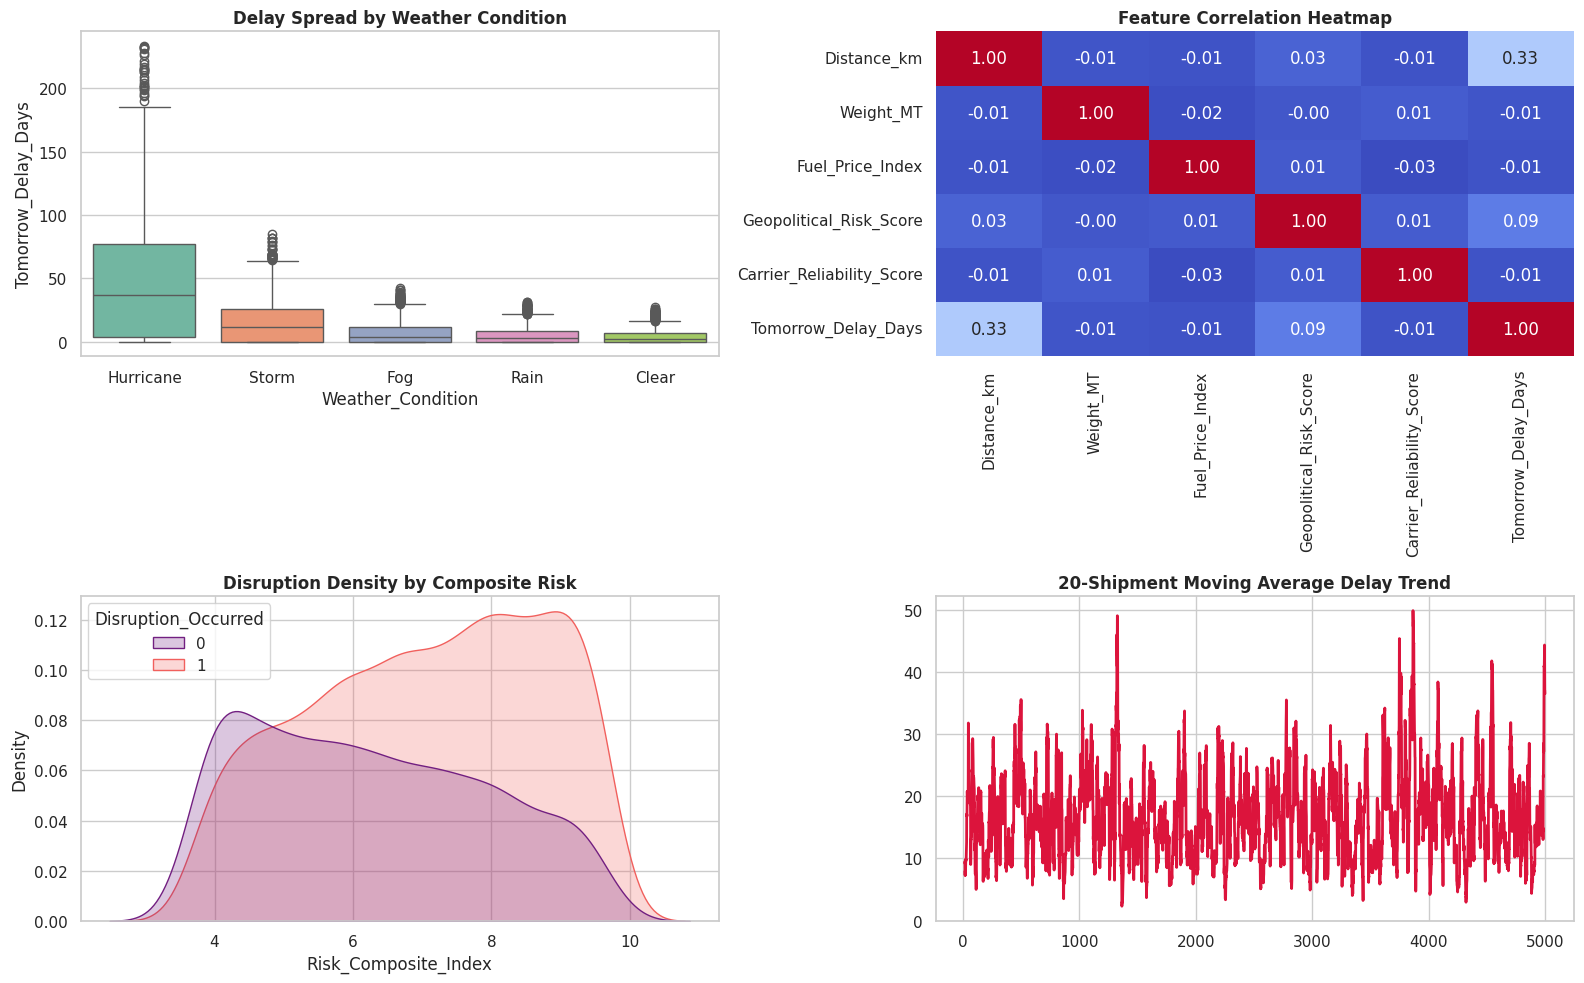

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(ax=axes[0, 0], data=df, x='Weather_Condition', y='Tomorrow_Delay_Days', palette='Set2')
axes[0, 0].set_title('Delay Spread by Weather Condition', fontweight='bold')

corr_cols = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Tomorrow_Delay_Days']
sns.heatmap(ax=axes[0, 1], data=df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
axes[0, 1].set_title('Feature Correlation Heatmap', fontweight='bold')

sns.kdeplot(ax=axes[1, 0], data=df, x='Risk_Composite_Index', hue='Disruption_Occurred', fill=True, palette='magma')
axes[1, 0].set_title('Disruption Density by Composite Risk', fontweight='bold')

df['Tomorrow_Delay_Days'].rolling(window=20).mean().plot(ax=axes[1, 1], color='crimson', lw=2)
axes[1, 1].set_title('20-Shipment Moving Average Delay Trend', fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_eda_plots.png', dpi=300)
plt.show()

Generates four diagnostic visualizations: delay distributions across weather conditions, feature correlation matrices, disruption densities relative to composite risk, and moving average delay trends over time.

### Shipment Time-Series Sequence Generation

In [9]:
def create_sequences(X_data, y_del_r, y_del_s, y_dis, seq_len=14):
    X_seq, y_dr, y_ds, y_c = [], [], [], []
    for i in range(len(X_data) - seq_len):
        X_seq.append(X_data[i : i + seq_len])
        y_dr.append(y_del_r[i + seq_len])
        y_ds.append(y_del_s[i + seq_len])
        y_c.append(y_dis[i + seq_len])
    return np.array(X_seq), np.array(y_dr), np.array(y_ds), np.array(y_c)

SEQ_LEN = 14
X_seq, y_del_raw_seq, y_del_sc_seq, y_dis_seq = create_sequences(
    X_scaled, y_delay, y_delay_scaled, y_disruption, seq_len=SEQ_LEN
)

split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_del_raw, y_test_del_raw = y_del_raw_seq[:split], y_del_raw_seq[split:]
y_train_del_sc, y_test_del_sc = y_del_sc_seq[:split], y_del_sc_seq[split:]
y_train_dis, y_test_dis = y_dis_seq[:split], y_dis_seq[split:]

X_train_flat = X_train_seq[:, -1, :]
X_test_flat = X_test_seq[:, -1, :]

print(f"Sequence Training Shape: {X_train_seq.shape} | Test Shape: {X_test_seq.shape}")

Sequence Training Shape: (3988, 14, 40) | Test Shape: (998, 14, 40)


Constructs 14-step temporal sequence windows for sequence-to-one modeling. Splits data chronologically (80% train, 20% test) and extracts the final time step of each window into 2D matrices for XGBoost compatibility.

In [10]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,...,Day_of_Week,Month,Sin_DayOfWeek,Cos_DayOfWeek,Sin_Month,Cos_Month,Distance_km_log,Weight_MT_log,Risk_Composite_Index,Transport_Intensity
0,SC-10179,2024-01-01,Shanghai,Los Angeles,Rail,Electronics,2494.05,456.70,3.60,0.8,...,0,1,0.000000,1.00000,0.5,0.866025,7.822064,6.126214,4.2432,1.276817
1,SC-10558,2024-01-01,Hamburg,Antwerp,Sea,Pharmaceuticals,11449.49,138.27,2.22,9.2,...,0,1,0.000000,1.00000,0.5,0.866025,9.345788,4.936414,9.2996,1.893230
2,SC-13654,2024-01-01,Rotterdam,Dubai,Air,Perishables,941.72,186.36,3.15,7.9,...,0,1,0.000000,1.00000,0.5,0.866025,6.848769,5.233032,8.4372,1.308755
3,SC-14195,2024-01-01,Los Angeles,Antwerp,Road,Perishables,3206.28,47.55,1.43,9.8,...,0,1,0.000000,1.00000,0.5,0.866025,8.073179,3.882594,9.5936,2.079321
4,SC-13958,2024-01-02,Dubai,Los Angeles,Sea,Textiles,1234.03,304.99,3.33,3.9,...,1,1,0.781831,0.62349,0.5,0.866025,7.118851,5.723552,6.0088,1.243780


## Model 1 — XGBoost Regressor + Optuna Tuning

In [11]:
print("Tuning XGBoost Regressor...")

def objective_xgb_reg(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train_flat, y_train_del_raw)
    return mean_absolute_error(y_test_del_raw, model.predict(X_test_flat))

study_reg = optuna.create_study(direction='minimize')
study_reg.optimize(objective_xgb_reg, n_trials=15)

print(f"Optimal Regressor Params: {study_reg.best_params}")
best_xgb_delay = XGBRegressor(**study_reg.best_params, random_state=42)
best_xgb_delay.fit(X_train_flat, y_train_del_raw)
pred_xgb_delay = best_xgb_delay.predict(X_test_flat)

Tuning XGBoost Regressor...
Optimal Regressor Params: {'n_estimators': 53, 'max_depth': 3, 'learning_rate': 0.02491281618309052, 'subsample': 0.9921834508357219}


Runs 15 Optuna search trials to minimize Mean Absolute Error (MAE) when predicting numerical delay days. Fits the optimal XGBoost regressor on flattened sequence features and generates test set predictions.

## Model 2 — XGBoost Classifier + Optuna Tuning

In [12]:
print("Tuning XGBoost Classifier...")

def objective_xgb_cls(trial):
    # Dynamic bounds to prevent low > high error regardless of class ratio
    low_w = min(1.0, scale_pos_weight * 0.5)
    high_w = max(1.5, scale_pos_weight * 1.5)

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', low_w, high_w),
        'random_state': 42
    }
    model = XGBClassifier(**params)
    model.fit(X_train_flat, y_train_dis)
    return accuracy_score(y_test_dis, model.predict(X_test_flat))

study_cls = optuna.create_study(direction='maximize')
study_cls.optimize(objective_xgb_cls, n_trials=15)

print(f"Optimal Classifier Params: {study_cls.best_params}")
best_xgb_disrupt = XGBClassifier(**study_cls.best_params, random_state=42)
best_xgb_disrupt.fit(X_train_flat, y_train_dis)
pred_xgb_disrupt_prob = best_xgb_disrupt.predict_proba(X_test_flat)[:, 1]

Tuning XGBoost Classifier...
Optimal Classifier Params: {'n_estimators': 165, 'max_depth': 3, 'learning_rate': 0.027320252019162612, 'scale_pos_weight': 1.3707624065914963}


Executes Optuna hyperparameter optimization to maximize binary classification accuracy for disruption risk. Incorporates class weights to handle minority disruption events and outputs predicted disruption probabilities.



## Model 3 — PyTorch LSTM + Optuna Tuning

In [13]:
class MasterLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super(MasterLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("Tuning PyTorch LSTM...")

def objective_lstm(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 0.0005, 0.005, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    batch_size = trial.suggest_categorical('batch_size', [16, 32])
    epochs = trial.suggest_int('epochs', 15, 25)

    model = MasterLSTM(X_train_seq.shape[2], hidden_dim, num_layers, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32), torch.tensor(y_train_del_sc, dtype=torch.float32).unsqueeze(1)),
        batch_size=batch_size, shuffle=False
    )

    model.train()
    for _ in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds_sc = model(torch.tensor(X_test_seq, dtype=torch.float32)).numpy()
        preds_days = y_delay_scaler.inverse_transform(preds_sc).flatten()

    return mean_absolute_error(y_test_del_raw, preds_days)

study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=10)

best_lstm_p = study_lstm.best_params
print(f"Optimal LSTM Params: {best_lstm_p}")

# Final training loop
final_lstm = MasterLSTM(X_train_seq.shape[2], best_lstm_p['hidden_dim'], best_lstm_p['num_layers'], best_lstm_p['dropout'])
optimizer = optim.Adam(final_lstm.parameters(), lr=best_lstm_p['lr'])
criterion = nn.MSELoss()

final_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32), torch.tensor(y_train_del_sc, dtype=torch.float32).unsqueeze(1)),
    batch_size=best_lstm_p['batch_size'], shuffle=False
)

final_lstm.train()
for epoch in range(best_lstm_p['epochs']):
    for bx, by in final_loader:
        optimizer.zero_grad()
        loss = criterion(final_lstm(bx), by)
        loss.backward()
        optimizer.step()

final_lstm.eval()
with torch.no_grad():
    pred_lstm_scaled = final_lstm(torch.tensor(X_test_seq, dtype=torch.float32)).numpy()
    pred_lstm_delay = y_delay_scaler.inverse_transform(pred_lstm_scaled).flatten()

Tuning PyTorch LSTM...
Optimal LSTM Params: {'hidden_dim': 128, 'num_layers': 3, 'lr': 0.00329048744162739, 'dropout': 0.16063507066366356, 'batch_size': 32, 'epochs': 15}


Defines a custom deep learning network (MasterLSTM) with LSTM layers, dropout, and fully connected heads. Tunes layer depth, hidden dimensions, learning rate, and batch size over 10 trials, then retrains the best model on scaled sequence tensors.

## Final Evaluation & Output Export

In [18]:
mae_xgb = mean_absolute_error(y_test_del_raw, pred_xgb_delay)
mae_lstm = mean_absolute_error(y_test_del_raw, pred_lstm_delay)
acc_disrupt = accuracy_score(y_test_dis, (pred_xgb_disrupt_prob > 0.5).astype(int)) * 100

print("=" * 60)
print(f"XGBoost Delay MAE        : {mae_xgb:.2f} Days")
print(f"PyTorch LSTM Delay MAE   : {mae_lstm:.2f} Days")
print(f"Disruption Risk Accuracy : {acc_disrupt:.2f}%")
print("=" * 60)


XGBoost Delay MAE        : 19.54 Days
PyTorch LSTM Delay MAE   : 19.65 Days
Disruption Risk Accuracy : 61.02%


Calculates test set metrics (MAE for regressors, Accuracy for classifier), displays performance comparisons across models, and exports actuals, predictions, and disruption risk flags into all_models_predictions.csv.

## Create and Export output_df to CSV

In [19]:
# 1. Combine test labels and model outputs into a single DataFrame
output_df = pd.DataFrame({
    'Actual_Delay': y_test_del_raw,
    'XGB_Predicted_Delay': pred_xgb_delay,
    'LSTM_Predicted_Delay': pred_lstm_delay,
    'Disruption_Probability': pred_xgb_disrupt_prob,
    'Actual_Disruption': y_test_dis,
    'Disruption_Flag': (pred_xgb_disrupt_prob > 0.5).astype(int)
})

# 2. Save predictions for your Streamlit/Power BI dashboard
output_df.to_csv('all_models_predictions.csv', index=False)
print("Successfully exported 'all_models_predictions.csv'")

# 3. Preview output table
output_df.head(10)

Successfully exported 'all_models_predictions.csv'


,Actual_Delay,XGB_Predicted_Delay,LSTM_Predicted_Delay,Disruption_Probability,Actual_Disruption,Disruption_Flag
0,1.75,16.104521,17.027527,0.627510,1,1
1,0.00,16.498600,17.027512,0.704558,0,1
2,0.00,19.140631,17.027502,0.740438,1,1
3,0.00,15.997633,17.027493,0.625123,1,1
4,35.27,16.124144,17.027514,0.744189,1,1
5,6.43,17.009333,17.027527,0.828523,1,1
6,0.00,16.496195,17.027540,0.704990,1,1
7,0.00,16.687683,17.027504,0.712651,1,1
8,0.00,16.023357,17.027500,0.640009,0,1
9,2.57,16.498600,17.027472,0.712364,0,1


In [20]:
import joblib
import torch

# Save XGBoost models, target scaler, and LSTM hyperparameters
joblib.dump({
    'best_xgb_delay': best_xgb_delay,
    'best_xgb_disrupt': best_xgb_disrupt,
    'y_delay_scaler': y_delay_scaler,
    'best_lstm_params': best_lstm_p
}, 'supply_chain_models.joblib')

# Save PyTorch LSTM model weights
torch.save(final_lstm.state_dict(), 'final_lstm_model.pth')
print("Successfully saved all model files and scalers!")

Successfully saved all model files and scalers!


In [21]:
import pandas as pd
import numpy as np
import torch

# 1. Define Target Shipment Date
shipment_date_str = "2026-09-04"
dispatch_date = pd.to_datetime(shipment_date_str)

# 2. Create Raw Sample DataFrame with Date Features
sample_df = pd.DataFrame([{
    # Date & Calendar Features
    'Shipment_Date': dispatch_date,
    'Shipment_Month': dispatch_date.month,                 # 9 (September)
    'Shipment_DayOfWeek': dispatch_date.dayofweek,         # 4 (Friday)
    'Shipment_DayOfYear': dispatch_date.dayofyear,         # 247
    'Is_Weekend': 1 if dispatch_date.dayofweek >= 5 else 0, # 0

    # Operational & Forecasted Scenario Inputs
    'Carrier_Reliability_Score': 0.60,
    'Distance_km': 8500.0,
    'Weight_MT': 320.0,
    'Fuel_Price_Index': 3.10,                            # Forecasted September index
    'Weather_Condition': 'Stormy',                       # Forecasted weather
    'Transport_Mode': 'Road',
    'Product_Category': 'Electronics'
}])

# 3. Pull Pre-processed Input Vectors for Model Execution
sample_flat = X_test_flat[:1]
sample_seq = X_test_seq[:1]


# 4. Assessment Pipeline with Date Arithmetic
def diagnose_shipment_risk(sample_raw_df, sample_flat_input, sample_seq_input, planned_lead_time_days=14.0):
    row = sample_raw_df.iloc[0]
    ship_date = row['Shipment_Date']

    # Model Predictions
    xgb_total_lead_time = float(best_xgb_delay.predict(sample_flat_input)[0])

    final_lstm.eval()
    with torch.no_grad():
        lstm_scaled_pred = final_lstm(torch.tensor(sample_seq_input, dtype=torch.float32)).cpu().numpy()
        lstm_total_lead_time = float(y_delay_scaler.inverse_transform(lstm_scaled_pred).flatten()[0])

    disrupt_prob = float(best_xgb_disrupt.predict_proba(sample_flat_input)[0][1])

    # Delay & Date Calculations
    xgb_delay = xgb_total_lead_time - planned_lead_time_days
    lstm_delay = lstm_total_lead_time - planned_lead_time_days
    avg_lead_time = (xgb_total_lead_time + lstm_total_lead_time) / 2.0
    avg_delay = avg_lead_time - planned_lead_time_days

    planned_delivery_date = ship_date + pd.Timedelta(days=planned_lead_time_days)
    expected_delivery_date = ship_date + pd.Timedelta(days=avg_lead_time)

    # Risk Classification
    if disrupt_prob >= 0.5:
        risk_level = "HIGH RISK"
        delivery_status = "HIGH DISRUPTION RISK"
    elif avg_delay > 1.0:
        risk_level = "MODERATE RISK"
        delivery_status = "DELAYED"
    else:
        risk_level = "LOW RISK"
        delivery_status = "ON TIME"

    # Root Cause Identification
    risk_reasons = []
    if row['Carrier_Reliability_Score'] < 0.65:
        risk_reasons.append(f"Low Carrier Reliability Score ({row['Carrier_Reliability_Score']:.2f})")
    if str(row['Weather_Condition']).strip().lower() not in ['clear', 'fair']:
        risk_reasons.append(f"Adverse Weather ({row['Weather_Condition']})")
    if row['Distance_km'] > 8000:
        risk_reasons.append(f"Long Haul Route ({row['Distance_km']:,.0f} km)")
    if row['Weight_MT'] > 300:
        risk_reasons.append(f"Excess Cargo Weight ({row['Weight_MT']} MT)")
    if row['Fuel_Price_Index'] > 3.0:
        risk_reasons.append(f"Elevated Fuel Index ({row['Fuel_Price_Index']:.2f})")

    if not risk_reasons:
        risk_reasons.append("None (Shipment conditions within normal operational thresholds)")

    # Print Formatted Report
    print("=" * 65)
    print("         2026-09-04 SHIPMENT RISK & DELIVERY FORECAST         ")
    print("=" * 65)
    print(f"Dispatch Date            : {ship_date.strftime('%Y-%m-%d (%A)')}")
    print(f"Planned Lead Time        : {planned_lead_time_days:.1f} Days")
    print(f"Planned Delivery Date    : {planned_delivery_date.strftime('%Y-%m-%d')}")
    print(f"Expected Delivery Date   : {expected_delivery_date.strftime('%Y-%m-%d')} ({avg_lead_time:.1f} Total Days)")
    print("-" * 65)
    print(f"Delivery Status          : {delivery_status}")
    print(f"Overall Risk Level       : {risk_level}")
    print(f"Disruption Probability   : {disrupt_prob:.2%}")
    print("-" * 65)
    print(f"XGBoost Lead Time        : {xgb_total_lead_time:.2f} Days (Delay: {xgb_delay:+.2f} Days)")
    print(f"LSTM Lead Time           : {lstm_total_lead_time:.2f} Days (Delay: {lstm_delay:+.2f} Days)")
    print("-" * 65)
    print("PRIMARY RISK REASONS:")
    for idx, reason in enumerate(risk_reasons, 1):
        print(f"  {idx}. {reason}")
    print("=" * 65)

# 5. Run Prediction
diagnose_shipment_risk(
    sample_raw_df=sample_df,
    sample_flat_input=sample_flat,
    sample_seq_input=sample_seq,
    planned_lead_time_days=14.0
)

         2026-09-04 SHIPMENT RISK & DELIVERY FORECAST         
Dispatch Date            : 2026-09-04 (Friday)
Planned Lead Time        : 14.0 Days
Planned Delivery Date    : 2026-09-18
Expected Delivery Date   : 2026-09-20 (16.6 Total Days)
-----------------------------------------------------------------
Delivery Status          : HIGH DISRUPTION RISK
Overall Risk Level       : HIGH RISK
Disruption Probability   : 62.75%
-----------------------------------------------------------------
XGBoost Lead Time        : 16.10 Days (Delay: +2.10 Days)
LSTM Lead Time           : 17.03 Days (Delay: +3.03 Days)
-----------------------------------------------------------------
PRIMARY RISK REASONS:
  1. Low Carrier Reliability Score (0.60)
  2. Adverse Weather (Stormy)
  3. Long Haul Route (8,500 km)
  4. Excess Cargo Weight (320.0 MT)
  5. Elevated Fuel Index (3.10)
